In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

## DATA LOADING

In [35]:
df = pd.read_csv("NovaTrust Retail Bank  Analysis.csv")

df.head()


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


## DATA UNDERSTANDING

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

## KPI CREATION 


##  Core KPIs

In [4]:
total_loans = df['id'].count()
total_loan_amount = df['loan_amount'].sum()
total_payment = df['total_payment'].sum()
avg_interest_rate = df['int_rate'].mean()


print(total_loans)
print(total_loan_amount)
print(total_payment)
print(avg_interest_rate)

38576
435757075
473070933
0.12048831397760265


## Default KPI

In [5]:
df['default_flag'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

default_rate = df['default_flag'].mean()
print(default_rate)

0.13824657818332642


## Profit KPI

In [6]:
estimated_profit = total_payment - total_loan_amount
print(estimated_profit)

37313858


## kpi summary

In [7]:
kpi_df = pd.DataFrame({
    "KPI": [
        "Total Loans",
        "Total Loan Amount",
        "Total Payment Received",
        "Average Interest Rate",
        "Default Rate",
        "Estimated Profit"
    ],
    "Value": [
        total_loans,
        round(total_loan_amount,2),
        round(total_payment,2),
        round(avg_interest_rate*100,2),
        round(default_rate*100,2),
        round(estimated_profit,2)
    ]
})

kpi_df


,KPI,Value
0,Total Loans,3.857600e+04
1,Total Loan Amount,4.357571e+08
2,Total Payment Received,4.730709e+08
3,Average Interest Rate,1.205000e+01
4,Default Rate,1.382000e+01
5,Estimated Profit,3.731386e+07


## RISK & SEGMENTATION FEATURES

In [8]:
df['loan_to_income'] = df['loan_amount'] / df['annual_income']
df['risk_category'] = pd.cut(
    df['dti'],
    bins=[0,20,35,100],
    labels=['Low','Medium','High']
) 

df[['loan_to_income','risk_category']].head(10)

,loan_to_income,risk_category
0,0.083333,Low
1,0.062500,Low
2,0.240000,Low
3,0.107143,Low
4,0.042169,Low
5,0.285714,Low
6,0.063291,Low
7,0.093220,Low
8,0.206186,Low
9,0.114583,Low


## VISUAL ANALYSIS

## Loan Status Distribution

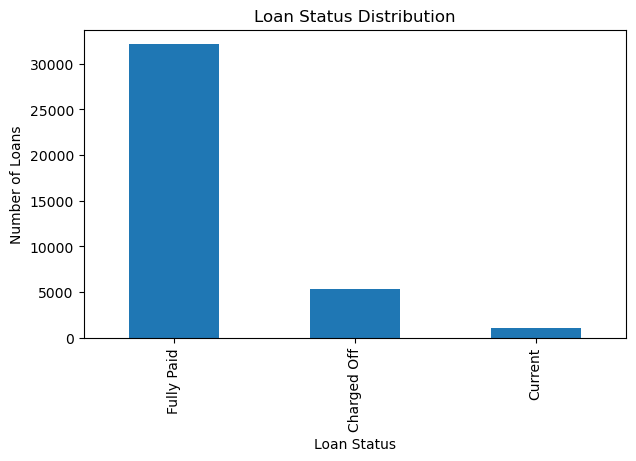

In [9]:
plt.figure(figsize=(7,4))
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.show()

## Default Rate by Grade 

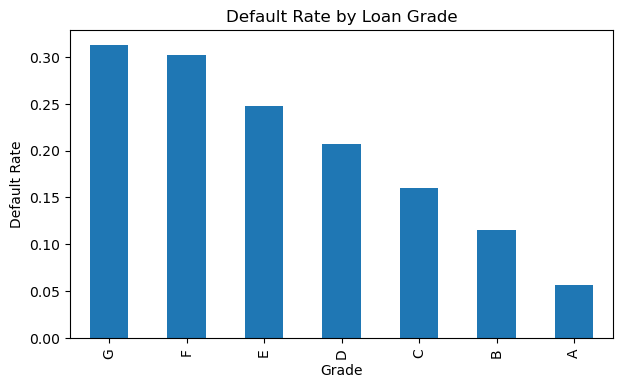

In [10]:
default_by_grade = df.groupby('grade')['default_flag'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
default_by_grade.plot(kind='bar')
plt.title("Default Rate by Loan Grade")
plt.xlabel("Grade")
plt.ylabel("Default Rate")
plt.show()

## Loan Amount by Risk Category

C:\Users\User\AppData\Local\Temp\ipykernel_7360\3569146366.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_amount = df.groupby('risk_category')['loan_amount'].sum()


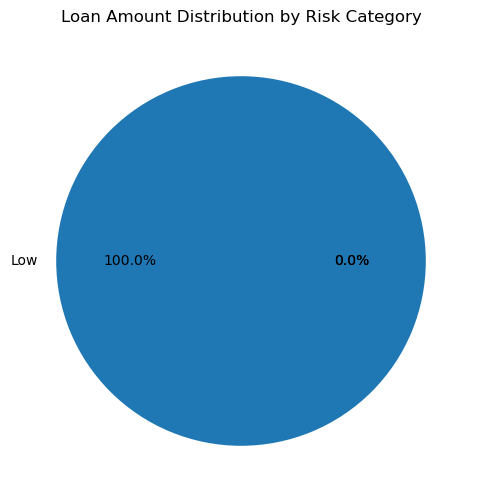

In [11]:
risk_amount = df.groupby('risk_category')['loan_amount'].sum()

plt.figure(figsize=(6,6))
sns.barplot
risk_amount.plot(kind='pie', autopct='%1.1f%%')
plt.title("Loan Amount Distribution by Risk Category")
plt.ylabel("")
plt.show()

## Interest Rate Distribution

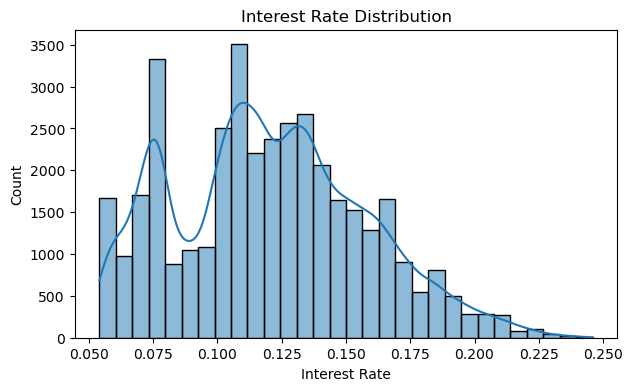

In [12]:
plt.figure(figsize=(7,4))
sns.histplot(df['int_rate'], bins=30, kde=True)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate")
plt.show()

## Income vs Loan Amount

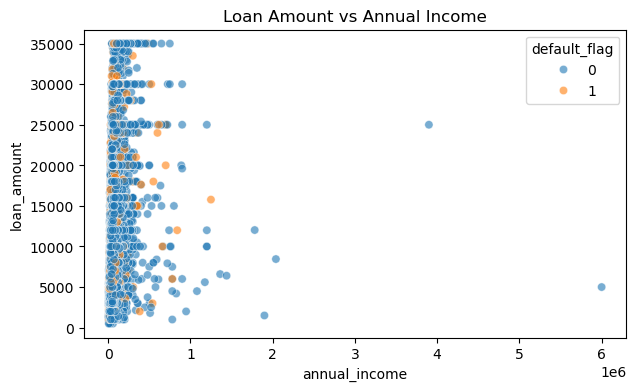

In [13]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    x='annual_income',
    y='loan_amount',
    hue='default_flag',
    data=df,
    alpha=0.6
)
plt.title("Loan Amount vs Annual Income")
plt.show()

## DTI vs Default

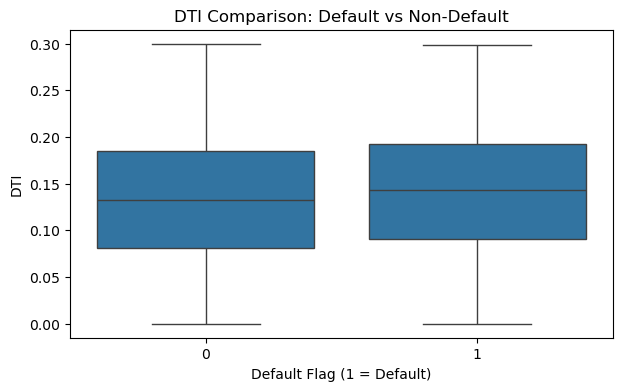

In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(
    x='default_flag',
    y='dti',
    data=df
)
plt.title("DTI Comparison: Default vs Non-Default")
plt.xlabel("Default Flag (1 = Default)")
plt.ylabel("DTI")
plt.show()

## Monthly Loan Trend

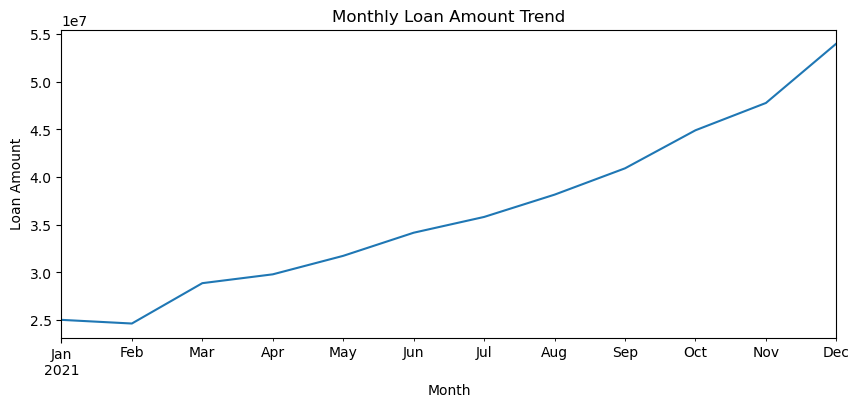

In [36]:
df['issue_date'] = pd.to_datetime(
    df['issue_date'],
    format='%d-%m-%Y',
    errors='coerce'
)

monthly_loan = df.groupby(df['issue_date'].dt.to_period('M'))['loan_amount'].sum()

monthly_loan.plot(figsize=(10,4))
plt.title("Monthly Loan Amount Trend")
plt.xlabel("Month")
plt.ylabel("Loan Amount")
plt.show()

## CREATE GOOD / BAD LOAN FLAG

In [19]:
good_status = ['Fully Paid', 'Current']
bad_status = ['Charged Off', 'Default', 'Late']

df['loan_quality'] = df['loan_status'].apply(
    lambda x: 'Good Loan' if x in good_status else 'Bad Loan'
)


In [ ]:
good_status = ['Fully Paid', 'Current']
bad_status = ['Charged Off', 'Default', 'Late']

df['loan_quality'] = df['loan_status'].apply(
    lambda x: 'bad Loan' if x in good_status else ' Loan'
)


## CORE KPIs – GOOD vs BAD LOANS

## Loan Count

In [18]:
loan_count = df.groupby('loan_status')['id'].count()
loan_count

loan_status
Charged Off     5333
Current         1098
Fully Paid     32145
Name: id, dtype: int64

## loan amount issused

In [20]:
loan_amount_issued = df.groupby('loan_status')['loan_amount'].sum()
loan_amount_issued


loan_status
Charged Off     65532225
Current         18866500
Fully Paid     351358350
Name: loan_amount, dtype: int64

## loan amount recevied

In [21]:
loan_amount_received = df.groupby('loan_status')['total_payment'].sum()
loan_amount_received


loan_status
Charged Off     37284763
Current         24199914
Fully Paid     411586256
Name: total_payment, dtype: int64

##  loan amount funded

In [22]:
loan_amount_funded = df.groupby('loan_status')['loan_amount'].sum()
loan_amount_funded


loan_status
Charged Off     65532225
Current         18866500
Fully Paid     351358350
Name: loan_amount, dtype: int64

## Good Loan Percentage

In [24]:
good_loans = loan_count.loc[['Current', 'Fully Paid']].sum()
total_loans = loan_count.sum()

good_loan_percentage = (good_loans / total_loans) * 100

good_loan_percentage

np.float64(86.17534218166736)

In [27]:
bad_loan_percentage = 100 - good_loan_percentage
bad_loan_percentage

np.float64(13.82465781833264)

## VISUAL ANALYSIS of Good and Bad Loan

## Loan Amount Issued – Good vs Bad

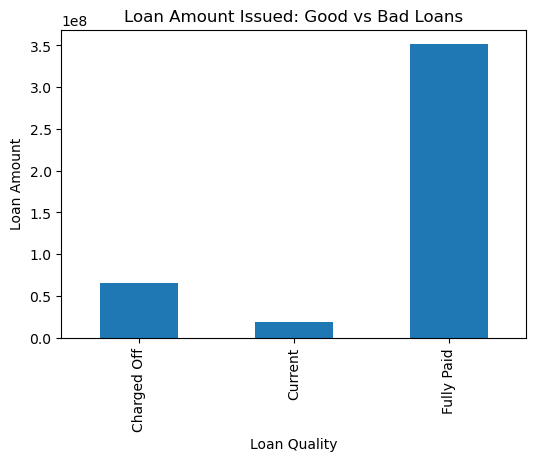

In [30]:
loan_amount_issued.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Loan Amount Issued: Good vs Bad Loans")
plt.xlabel("Loan Quality")
plt.ylabel("Loan Amount")
plt.show()


## Loan Amount Received – Good vs Bad

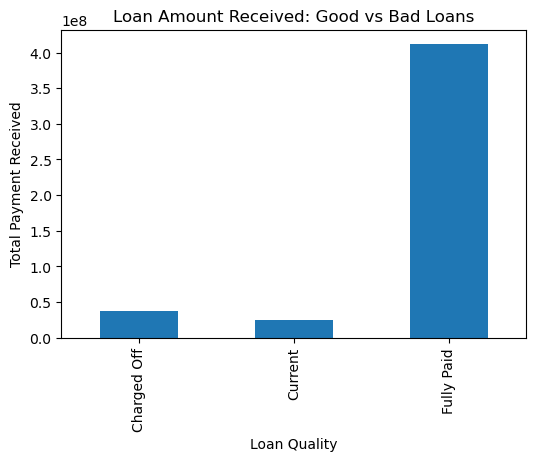

In [31]:
loan_amount_received.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Loan Amount Received: Good vs Bad Loans")
plt.xlabel("Loan Quality")
plt.ylabel("Total Payment Received")
plt.show()


## Loan Distribution % (Pie Chart)

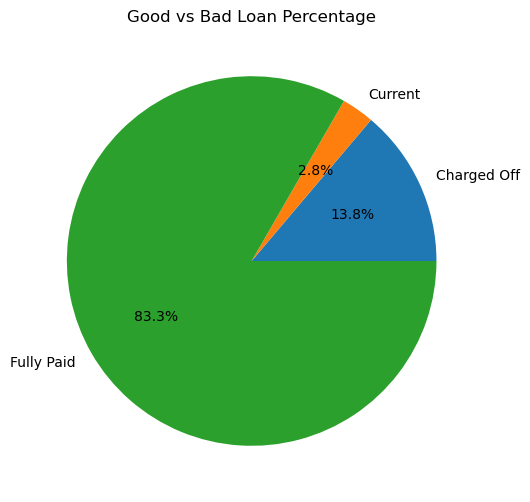

In [32]:
loan_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Good vs Bad Loan Percentage")
plt.ylabel("")
plt.show()


## Funded Amount Comparison

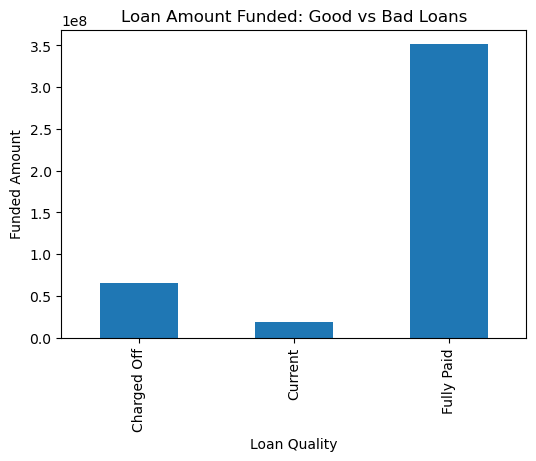

In [33]:
loan_amount_funded.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Loan Amount Funded: Good vs Bad Loans")
plt.xlabel("Loan Quality")
plt.ylabel("Funded Amount")
plt.show()
